# Bank Customer Churn Prediction
**Algorithms:** XGBoost · KNN · Naive Bayes  
**Dataset:** Bank Customer Churn (10,000 customers)  
**Goal:** Predict which customers will leave the bank and identify top churn drivers

## 1. Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, classification_report
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
print('All imports successful!')

All imports successful!


## 2. Load Data

In [4]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["churn"].mean():.1%}')
df.head()

Shape: (10000, 12)
Churn rate: 20.4%


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print('Column types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Column types:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Basic statistics:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Exploratory Data Analysis (EDA)

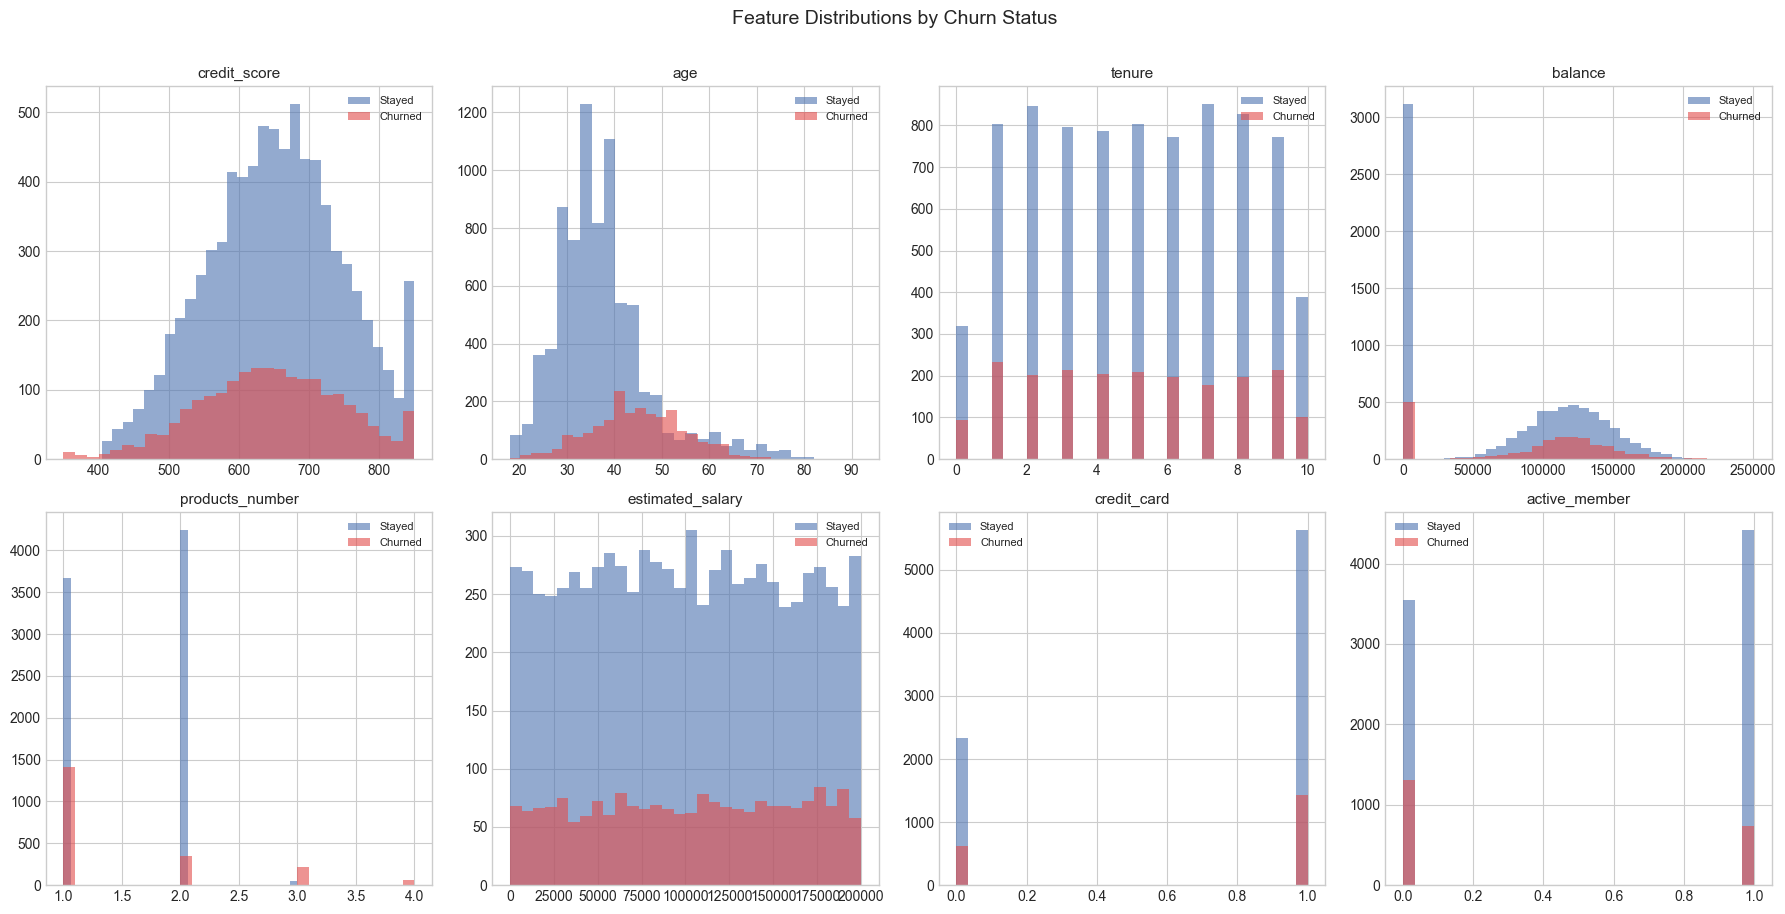

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature Distributions by Churn Status', fontsize=14, y=1.01)

num_cols = ['credit_score', 'age', 'tenure', 'balance',
            'products_number', 'estimated_salary', 'credit_card', 'active_member']

for ax, col in zip(axes.flatten(), num_cols):
    churned   = df[df['churn'] == 1][col]
    stayed    = df[df['churn'] == 0][col]
    ax.hist(stayed,  bins=30, alpha=0.6, label='Stayed', color='#4C72B0')
    ax.hist(churned, bins=30, alpha=0.6, label='Churned', color='#E24B4A')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

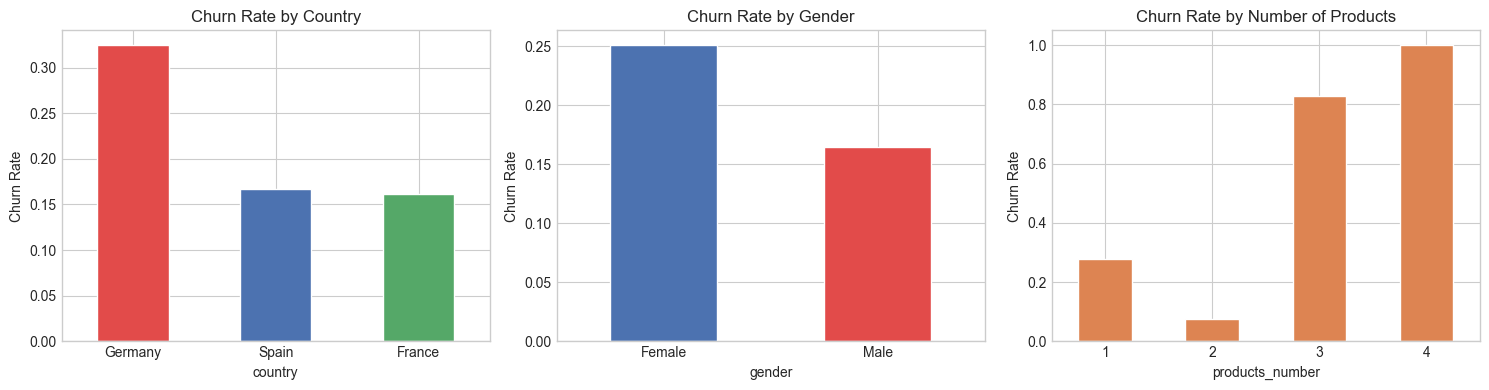

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn by Country
churn_country = df.groupby('country')['churn'].mean().sort_values(ascending=False)
churn_country.plot(kind='bar', ax=axes[0], color=['#E24B4A','#4C72B0','#55A868'], edgecolor='white')
axes[0].set_title('Churn Rate by Country', fontsize=12)
axes[0].set_ylabel('Churn Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Churn by Gender
churn_gender = df.groupby('gender')['churn'].mean()
churn_gender.plot(kind='bar', ax=axes[1], color=['#4C72B0','#E24B4A'], edgecolor='white')
axes[1].set_title('Churn Rate by Gender', fontsize=12)
axes[1].set_ylabel('Churn Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Churn by Number of Products
churn_prod = df.groupby('products_number')['churn'].mean()
churn_prod.plot(kind='bar', ax=axes[2], color='#DD8452', edgecolor='white')
axes[2].set_title('Churn Rate by Number of Products', fontsize=12)
axes[2].set_ylabel('Churn Rate')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

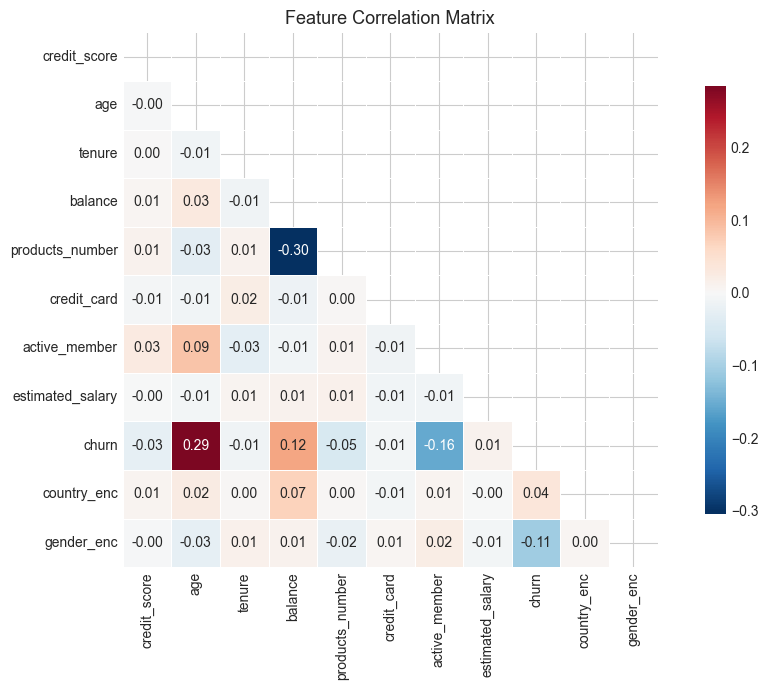

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
num_df = df.drop(columns=['customer_id'])
num_df['country_enc'] = LabelEncoder().fit_transform(num_df['country'])
num_df['gender_enc']  = LabelEncoder().fit_transform(num_df['gender'])
num_df = num_df.drop(columns=['country','gender'])

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [9]:
df_ml = df.copy()

# Drop non-predictive ID column
df_ml.drop(columns=['customer_id'], inplace=True)

# Encode categoricals
df_ml['country'] = LabelEncoder().fit_transform(df_ml['country'])
df_ml['gender']  = LabelEncoder().fit_transform(df_ml['gender'])

# --- Engineered Features ---

# 1. Balance per product
df_ml['balance_per_product'] = df_ml['balance'] / (df_ml['products_number'] + 1)

# 2. Age group (0=young, 1=mid, 2=senior, 3=old)
df_ml['age_group'] = pd.cut(df_ml['age'],
                             bins=[0, 30, 45, 60, 100],
                             labels=[0, 1, 2, 3]).astype(int)

# 3. Credit band
df_ml['credit_band'] = pd.cut(df_ml['credit_score'],
                               bins=[0, 580, 670, 740, 850],
                               labels=[0, 1, 2, 3]).astype(int)

# 4. Zero balance flag
df_ml['zero_balance'] = (df_ml['balance'] == 0).astype(int)

# 5. Engagement score
df_ml['engagement_score'] = (
    df_ml['active_member'] +
    df_ml['credit_card'] +
    df_ml['tenure'] / 10
)

# 6. Salary to balance ratio
df_ml['salary_balance_ratio'] = df_ml['estimated_salary'] / (df_ml['balance'] + 1)

# 7. High value customer
df_ml['high_value'] = (
    (df_ml['estimated_salary'] > df_ml['estimated_salary'].median()) &
    (df_ml['balance'] > df_ml['balance'].median())
).astype(int)

print(f'Features after engineering: {df_ml.shape[1] - 1}')
print('New features: balance_per_product, age_group, credit_band, zero_balance, engagement_score, salary_balance_ratio, high_value')
df_ml.head()

Features after engineering: 17
New features: balance_per_product, age_group, credit_band, zero_balance, engagement_score, salary_balance_ratio, high_value


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,balance_per_product,age_group,credit_band,zero_balance,engagement_score,salary_balance_ratio,high_value
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,0.00,1,1,1,2.2,101348.880000,0
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,41903.93,1,1,0,1.1,1.342848,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,39915.20,1,0,0,1.8,0.713581,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0.00,1,2,1,0.1,93826.630000,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,62755.41,1,3,0,2.2,0.630093,0


## 5. Train/Test Split & Scaling

In [10]:
X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'Train churn rate: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}')

Train: (8000, 17)  |  Test: (2000, 17)
Train churn rate: 20.4%  |  Test: 20.3%


## 6. Model Training

In [11]:
# ── XGBoost ──────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = 4,     # handles class imbalance
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = SEED,
    n_jobs            = -1
)
xgb_model.fit(X_train_s, y_train)
print('XGBoost trained!')

# ── KNN (tuned k) ─────────────────────────────────────────────
print('\nTuning KNN...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_k, best_auc = 3, 0
for k in range(3, 20, 2):
    knn_tmp = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    score   = cross_val_score(knn_tmp, X_train_s, y_train, cv=cv, scoring='roc_auc').mean()
    if score > best_auc:
        best_auc, best_k = score, k
print(f'Best k={best_k}  (CV AUC={best_auc:.4f})')

knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)
knn_model.fit(X_train_s, y_train)
print('KNN trained!')

# ── Naive Bayes ───────────────────────────────────────────────
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train)
print('Naive Bayes trained!')

XGBoost trained!

Tuning KNN...
Best k=19  (CV AUC=0.8044)
KNN trained!
Naive Bayes trained!


## 7. Model Evaluation

In [12]:
def evaluate_model(name, model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred  = model.predict(X)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y, pred),   4),
        'F1':        round(f1_score(y, pred),          4),
        'Precision': round(precision_score(y, pred),   4),
        'Recall':    round(recall_score(y, pred),      4),
        'ROC-AUC':   round(roc_auc_score(y, proba),    4),
    }

results = [
    evaluate_model('XGBoost',     xgb_model, X_test_s, y_test),
    evaluate_model('KNN',         knn_model, X_test_s, y_test),
    evaluate_model('Naive Bayes', nb_model,  X_test_s, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print('\n===== Model Comparison =====')
print(results_df.to_string())
results_df


===== Model Comparison =====
             Accuracy      F1  Precision  Recall  ROC-AUC
Model                                                    
XGBoost        0.8175  0.6170     0.5385  0.7224   0.8578
KNN            0.8360  0.4036     0.7762  0.2727   0.8080
Naive Bayes    0.7970  0.5000     0.5012  0.4988   0.7589


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
XGBoost,0.8175,0.6170,0.5385,0.7224,0.8578
KNN,0.8360,0.4036,0.7762,0.2727,0.8080
Naive Bayes,0.7970,0.5000,0.5012,0.4988,0.7589


In [13]:
# Classification report for best model
print('XGBoost Classification Report:')
print(classification_report(y_test, xgb_model.predict(X_test_s),
                             target_names=['Stay', 'Churn']))

XGBoost Classification Report:
              precision    recall  f1-score   support

        Stay       0.92      0.84      0.88      1593
       Churn       0.54      0.72      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



## 8. ROC Curves

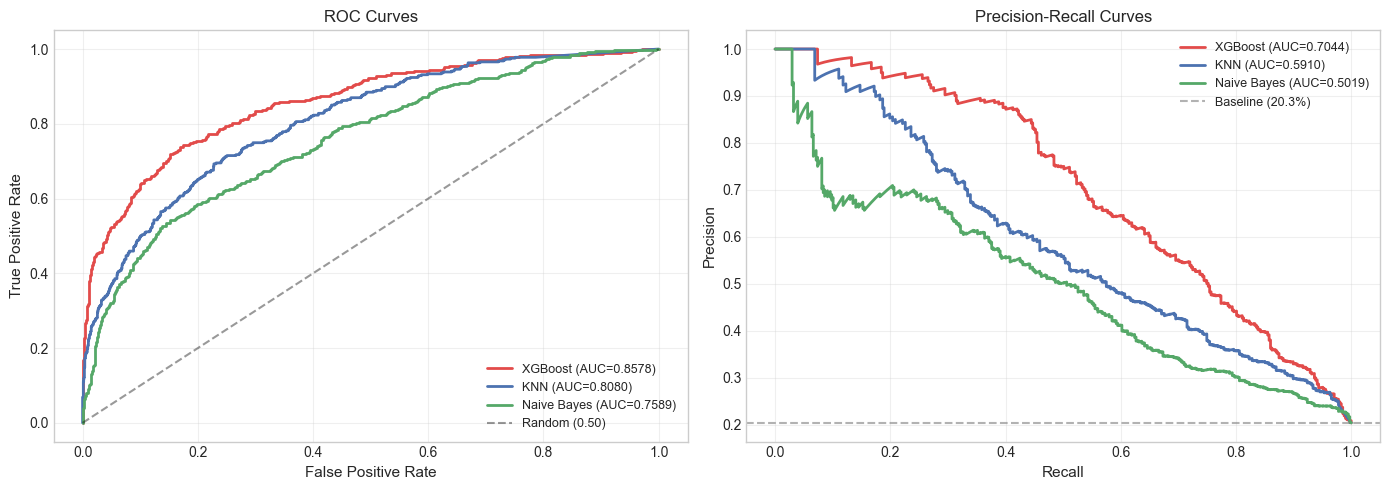

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = [
    ('XGBoost',     xgb_model, '#E24B4A'),
    ('KNN',         knn_model, '#4C72B0'),
    ('Naive Bayes', nb_model,  '#55A868'),
]

# ROC
for name, model, color in models_list:
    proba       = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={roc_auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random (0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate',  fontsize=11)
axes[0].set_title('ROC Curves',           fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Precision-Recall
for name, model, color in models_list:
    proba        = model.predict_proba(X_test_s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc       = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{name} (AUC={pr_auc:.4f})')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.6,
                label=f'Baseline ({y_test.mean():.1%})')
axes[1].set_xlabel('Recall',    fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Confusion Matrices

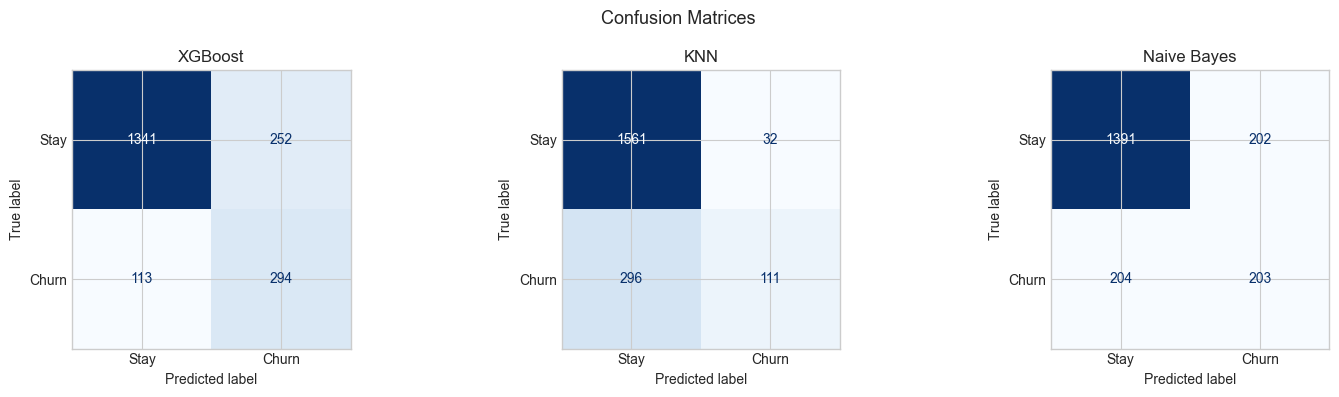

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, _) in zip(axes, models_list):
    cm   = confusion_matrix(y_test, model.predict(X_test_s))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stay','Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)
fig.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Learning Curve (XGBoost)

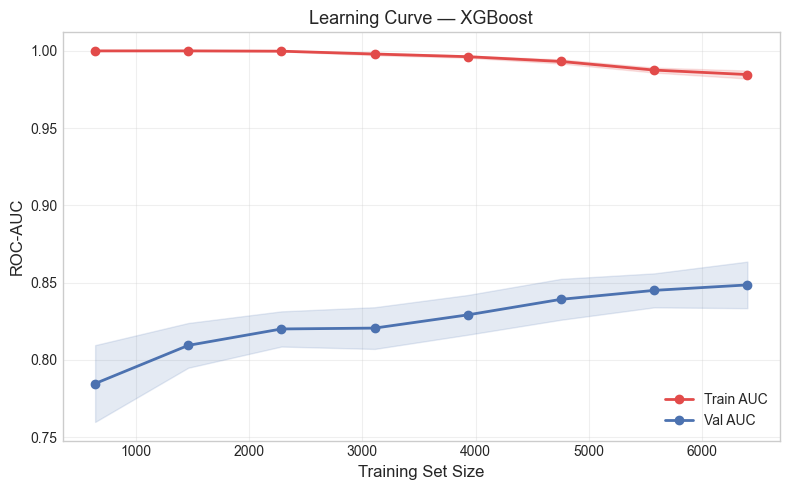

In [16]:
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
sizes, tr_scores, val_scores = learning_curve(
    XGBClassifier(n_estimators=100, max_depth=5, use_label_encoder=False,
                  eval_metric='logloss', random_state=SEED, n_jobs=-1),
    X_train_s, y_train,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = cv_lc,
    scoring     = 'roc_auc',
    n_jobs      = -1
)

plt.figure(figsize=(8, 5))
plt.plot(sizes, tr_scores.mean(axis=1),  'o-', color='#E24B4A', lw=2, label='Train AUC')
plt.fill_between(sizes,
    tr_scores.mean(axis=1) - tr_scores.std(axis=1),
    tr_scores.mean(axis=1) + tr_scores.std(axis=1), alpha=0.15, color='#E24B4A')
plt.plot(sizes, val_scores.mean(axis=1), 'o-', color='#4C72B0', lw=2, label='Val AUC')
plt.fill_between(sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#4C72B0')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('ROC-AUC',           fontsize=12)
plt.title('Learning Curve — XGBoost', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Feature Importance (XGBoost + SHAP)

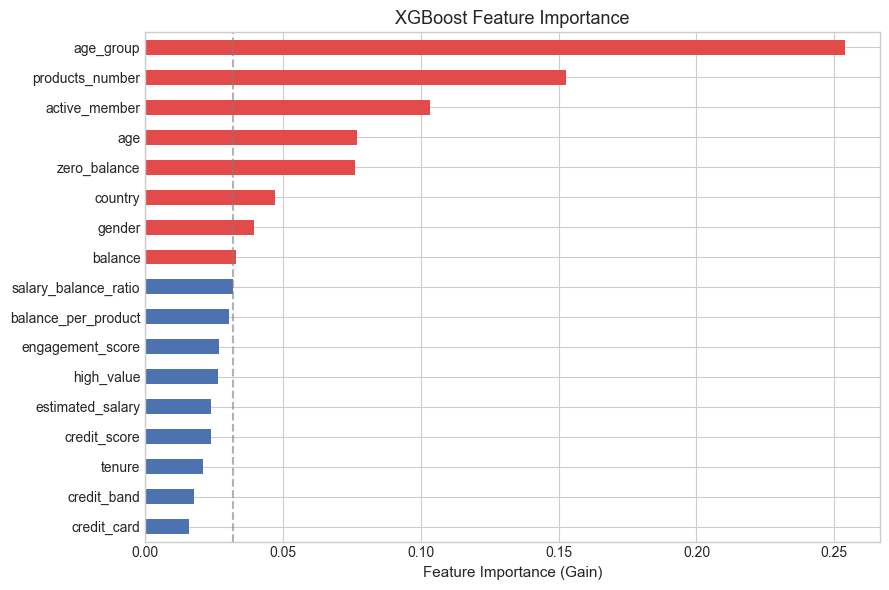


Top 5 Churn Drivers:
  1. age_group                 0.2539
  2. products_number           0.1528
  3. active_member             0.1033
  4. age                       0.0768
  5. zero_balance              0.0762


In [17]:
# XGBoost built-in feature importance
fi = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(9, 6))
colors = ['#E24B4A' if v > fi.median() else '#4C72B0' for v in fi]
fi.plot(kind='barh', color=colors)
plt.axvline(fi.median(), color='gray', linestyle='--', alpha=0.6)
plt.xlabel('Feature Importance (Gain)', fontsize=11)
plt.title('XGBoost Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop 5 Churn Drivers:')
for i, (feat, val) in enumerate(fi.sort_values(ascending=False).head(5).items(), 1):
    print(f'  {i}. {feat:<25} {val:.4f}')

## 13. Cross-Validation Summary

In [20]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name, model in [('XGBoost', xgb_model), ('KNN', knn_model), ('Naive Bayes', nb_model)]:
    aucs = cross_val_score(model, X_train_s, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1)
    accs = cross_val_score(model, X_train_s, y_train, cv=cv5, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model':       name,
        'CV AUC Mean': round(aucs.mean(), 4),
        'CV AUC Std':  round(aucs.std(),  4),
        'CV Acc Mean': round(accs.mean(), 4),
        'Test AUC':    round(roc_auc_score(y_test, model.predict_proba(X_test_s)[:,1]), 4),
        'Test Acc':    round(accuracy_score(y_test, model.predict(X_test_s)), 4),
    })

cv_df = pd.DataFrame(cv_results).set_index('Model')
print('\n===== Final Cross-Validation Summary =====')
cv_df


===== Final Cross-Validation Summary =====


,CV AUC Mean,CV AUC Std,CV Acc Mean,Test AUC,Test Acc
Model,,,,,
XGBoost,0.8577,0.0115,0.8190,0.8578,0.8175
KNN,0.8044,0.0166,0.8339,0.8080,0.8360
Naive Bayes,0.7574,0.0149,0.7910,0.7589,0.7970


## 14. Save Models

In [21]:
import pickle, os
os.makedirs('models', exist_ok=True)

with open('models/xgboost.pkl',     'wb') as f: pickle.dump(xgb_model, f)
with open('models/knn.pkl',         'wb') as f: pickle.dump(knn_model,  f)
with open('models/naive_bayes.pkl', 'wb') as f: pickle.dump(nb_model,   f)
with open('models/scaler.pkl',      'wb') as f: pickle.dump(scaler,     f)
with open('models/features.pkl',    'wb') as f: pickle.dump(feature_names, f)

print('All models saved to models/')

All models saved to models/


## 15. Predict a Single Customer

In [22]:
# Example: predict churn for a new customer
new_customer = pd.DataFrame([{
    'credit_score':     600,
    'country':          'Germany',
    'gender':           'Female',
    'age':              45,
    'tenure':           3,
    'balance':          125000,
    'products_number':  1,
    'credit_card':      1,
    'active_member':    0,
    'estimated_salary': 80000,
}])

# Apply same encoding + engineering
nc = new_customer.copy()
nc['country'] = LabelEncoder().fit(['France','Germany','Spain']).transform(nc['country'])
nc['gender']  = LabelEncoder().fit(['Female','Male']).transform(nc['gender'])
nc['balance_per_product']  = nc['balance'] / (nc['products_number'] + 1)
nc['age_group']            = pd.cut(nc['age'], bins=[0,30,45,60,100], labels=[0,1,2,3]).astype(int)
nc['credit_band']          = pd.cut(nc['credit_score'], bins=[0,580,670,740,850], labels=[0,1,2,3]).astype(int)
nc['zero_balance']         = (nc['balance'] == 0).astype(int)
nc['engagement_score']     = nc['active_member'] + nc['credit_card'] + nc['tenure'] / 10
nc['salary_balance_ratio'] = nc['estimated_salary'] / (nc['balance'] + 1)
nc['high_value']           = ((nc['estimated_salary'] > df_ml['estimated_salary'].median()) &
                               (nc['balance'] > df_ml['balance'].median())).astype(int)

nc_s   = scaler.transform(nc[feature_names])
prob   = xgb_model.predict_proba(nc_s)[0, 1]
risk   = 'HIGH' if prob > 0.6 else 'MEDIUM' if prob > 0.35 else 'LOW'

print(f'Churn Probability : {prob:.1%}')
print(f'Risk Level        : {risk}')
if risk == 'HIGH':
    print('Recommendation    : Immediate retention offer — loyalty bonus or fee waiver')
elif risk == 'MEDIUM':
    print('Recommendation    : Send personalised product recommendation')
else:
    print('Recommendation    : No action needed — monitor next quarter')

Churn Probability : 85.0%
Risk Level        : HIGH
Recommendation    : Immediate retention offer — loyalty bonus or fee waiver
